# Lab: Customer Segmentation Using Clustering (Credit Card Data)

## 1. Lab Title & Objectives

### Lab Title  
**Customer Segmentation with Unsupervised Clustering**

### Objectives  
In this lab, you will practice applying **unsupervised clustering algorithms** to a real-world dataset.  
The focus is on **data preparation, algorithm choice, and interpretation**, not on prediction accuracy.

By the end of this lab, you should understand:
- How clustering differs from supervised learning
- How preprocessing decisions affect clustering results
- How to interpret clusters from a **data science and business perspective**

This lab is **exploratory**: there are no labels and no “correct” answers.

---

## 2. Dataset Overview

### Business Context  
The dataset represents **credit card usage behavior** of active customers.  
The business goal is **customer segmentation** to support marketing strategy, such as:
- identifying high-value customers
- understanding spending patterns
- tailoring products or offers

### Dataset Description  
- Approximately **9000 credit card holders**
- Behavior summarized over the **last 6 months**
- **Customer-level** data (one row per customer)
- **18 numerical features** describing usage patterns

Each feature reflects **how customers use their credit cards**, not who they are.

---

## 3. High-Level Data Science Workflow (MANDATORY)

When clustering real data, a data scientist typically follows these steps:

- **Understand the data**
  - What does each feature represent?
  - What kind of behavior might it capture?

- **Clean and preprocess**
  - Handle missing values
  - Remove non-informative identifiers

- **Scale features**
  - Ensure all variables contribute fairly to distance calculations

- **Choose a clustering algorithm**
  - Based on data size, assumptions, and interpretability

- **Evaluate clustering quality**
  - Use diagnostic tools (not ground truth)
  - Balance metrics with interpretability

- **Interpret clusters**
  - Translate numeric patterns into meaningful profiles
  - Relate clusters to the business context

Clustering is **iterative**: insights often lead back to earlier steps.

---

## 4. Data Preparation Steps

Before applying clustering, consider the following steps:

- **Handling missing values**
  - Identify features with missing values
  - Decide whether to impute, remove rows, or remove features
  - Consider how missingness may reflect customer behavior

- **Removing identifier columns**
  - Drop columns such as customer IDs
  - Identifiers do not carry behavioral information and can distort clustering

- **Feature scaling**
  - Apply standardization or normalization
  - Required because clustering relies on distance calculations
  - Without scaling, features with large numeric ranges dominate

- **Optional: Dimensionality reduction (PCA)**
  - Can help with visualization
  - Can reduce noise and redundancy
  - Should be used carefully to preserve interpretability

---

## 5. Clustering Algorithms to Practice

### K-Means (Mandatory)

Why K-Means:
- Simple and widely used
- Scales well to large datasets
- Easy to interpret cluster centroids

Key assumptions:
- Clusters are roughly spherical
- Distance to the cluster center is meaningful
- Features are properly scaled

What to observe:
- How cluster centers differ
- How customers are distributed across clusters
- Sensitivity to the number of clusters

### Optional (Brief Exploration)
- **Hierarchical Clustering**: useful for visualizing cluster structure
- **DBSCAN**: useful for detecting noise and irregular clusters

These are optional extensions if time allows.

---

## 6. Model Selection & Evaluation

Because clustering is unsupervised, evaluation is **diagnostic**, not definitive.

Common approaches:
- **Elbow method**
  - Look at how within-cluster variation decreases
  - Identify diminishing returns when adding more clusters

- **Silhouette score**
  - Measures separation between clusters
  - Higher values suggest better-defined clusters

- **Practical interpretability**
  - Can you explain clusters meaningfully?
  - Do clusters differ in important behavioral features?

Final choice of number of clusters should balance:
- Quantitative signals
- Business usefulness
- Simplicity

---

## 7. Cluster Interpretation

After clustering, focus on **understanding the clusters**:

- **Profile clusters**
  - Compute average values of features per cluster
  - Identify dominant behaviors (e.g., high spending, frequent cash advances)

- **Translate to business meaning**
  - Describe clusters in plain language
  - Example: “Low balance, frequent installment users”

- **Avoid over-interpretation**
  - Clusters describe patterns, not individuals
  - Boundaries between clusters are not absolute

**Important reminder:**  
Clusters are **descriptive**, not ground truth.

---

## 8. Expected Learning Outcomes

After completing this lab, you should be able to:

- Explain how clustering differs from supervised learning
- Prepare real-world behavioral data for clustering
- Apply K-Means and justify preprocessing choices
- Reason about the number of clusters
- Interpret clusters in a business-relevant way
- Critically question clustering results and limitations

---

## 9. Optional Extensions (Bonus)

If time permits, explore one or more of the following:

- Compare K-Means with another clustering algorithm
- Visualize clusters using PCA
- Study how changing feature scaling affects clusters
- Propose hypothetical marketing strategies for each cluster
- Analyze cluster stability under different random initializations

---

### Final Note

This lab is about **thinking like a data scientist**, not finding a single correct answer.  
Your reasoning and interpretation matter more than the algorithm itself.


---

# 1. Import Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as shc

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 2. Load Data

In [4]:
df = pd.read_csv('CC GENERAL.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
df.shape

(8950, 18)

# 3. Data Exploration

## 3.1. Data Overview

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [7]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## 3.2. Missing Values

In [8]:
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [9]:
df.isna().sum() / len(df)

,0
CUST_ID,0.000000
BALANCE,0.000000
BALANCE_FREQUENCY,0.000000
PURCHASES,0.000000
ONEOFF_PURCHASES,0.000000
INSTALLMENTS_PURCHASES,0.000000
CASH_ADVANCE,0.000000
PURCHASES_FREQUENCY,0.000000
ONEOFF_PURCHASES_FREQUENCY,0.000000
PURCHASES_INSTALLMENTS_FREQUENCY,0.000000


In [10]:
df[df['CREDIT_LIMIT'].isna()]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
5203,C15349,18.400472,0.166667,0.0,0.0,0.0,186.853063,0.0,0.0,0.0,0.166667,1,0,NaN,9.040017,14.418723,0.0,6


## 3.3. Duplicates

In [11]:
df.duplicated().sum()

np.int64(0)

## 3.4. Cardinality

In [12]:
for col in df.columns:
    print(col, ":", df[col].nunique())

CUST_ID : 8950
BALANCE : 8871
BALANCE_FREQUENCY : 43
PURCHASES : 6203
ONEOFF_PURCHASES : 4014
INSTALLMENTS_PURCHASES : 4452
CASH_ADVANCE : 4323
PURCHASES_FREQUENCY : 47
ONEOFF_PURCHASES_FREQUENCY : 47
PURCHASES_INSTALLMENTS_FREQUENCY : 47
CASH_ADVANCE_FREQUENCY : 54
CASH_ADVANCE_TRX : 65
PURCHASES_TRX : 173
CREDIT_LIMIT : 205
PAYMENTS : 8711
MINIMUM_PAYMENTS : 8636
PRC_FULL_PAYMENT : 47
TENURE : 7


## 3.5. Distributions

array([[<Axes: title={'center': 'BALANCE'}>,
        <Axes: title={'center': 'BALANCE_FREQUENCY'}>,
        <Axes: title={'center': 'PURCHASES'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES'}>],
       [<Axes: title={'center': 'INSTALLMENTS_PURCHASES'}>,
        <Axes: title={'center': 'CASH_ADVANCE'}>,
        <Axes: title={'center': 'PURCHASES_FREQUENCY'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES_FREQUENCY'}>],
       [<Axes: title={'center': 'PURCHASES_INSTALLMENTS_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_TRX'}>,
        <Axes: title={'center': 'PURCHASES_TRX'}>],
       [<Axes: title={'center': 'CREDIT_LIMIT'}>,
        <Axes: title={'center': 'PAYMENTS'}>,
        <Axes: title={'center': 'MINIMUM_PAYMENTS'}>,
        <Axes: title={'center': 'PRC_FULL_PAYMENT'}>],
       [<Axes: title={'center': 'TENURE'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

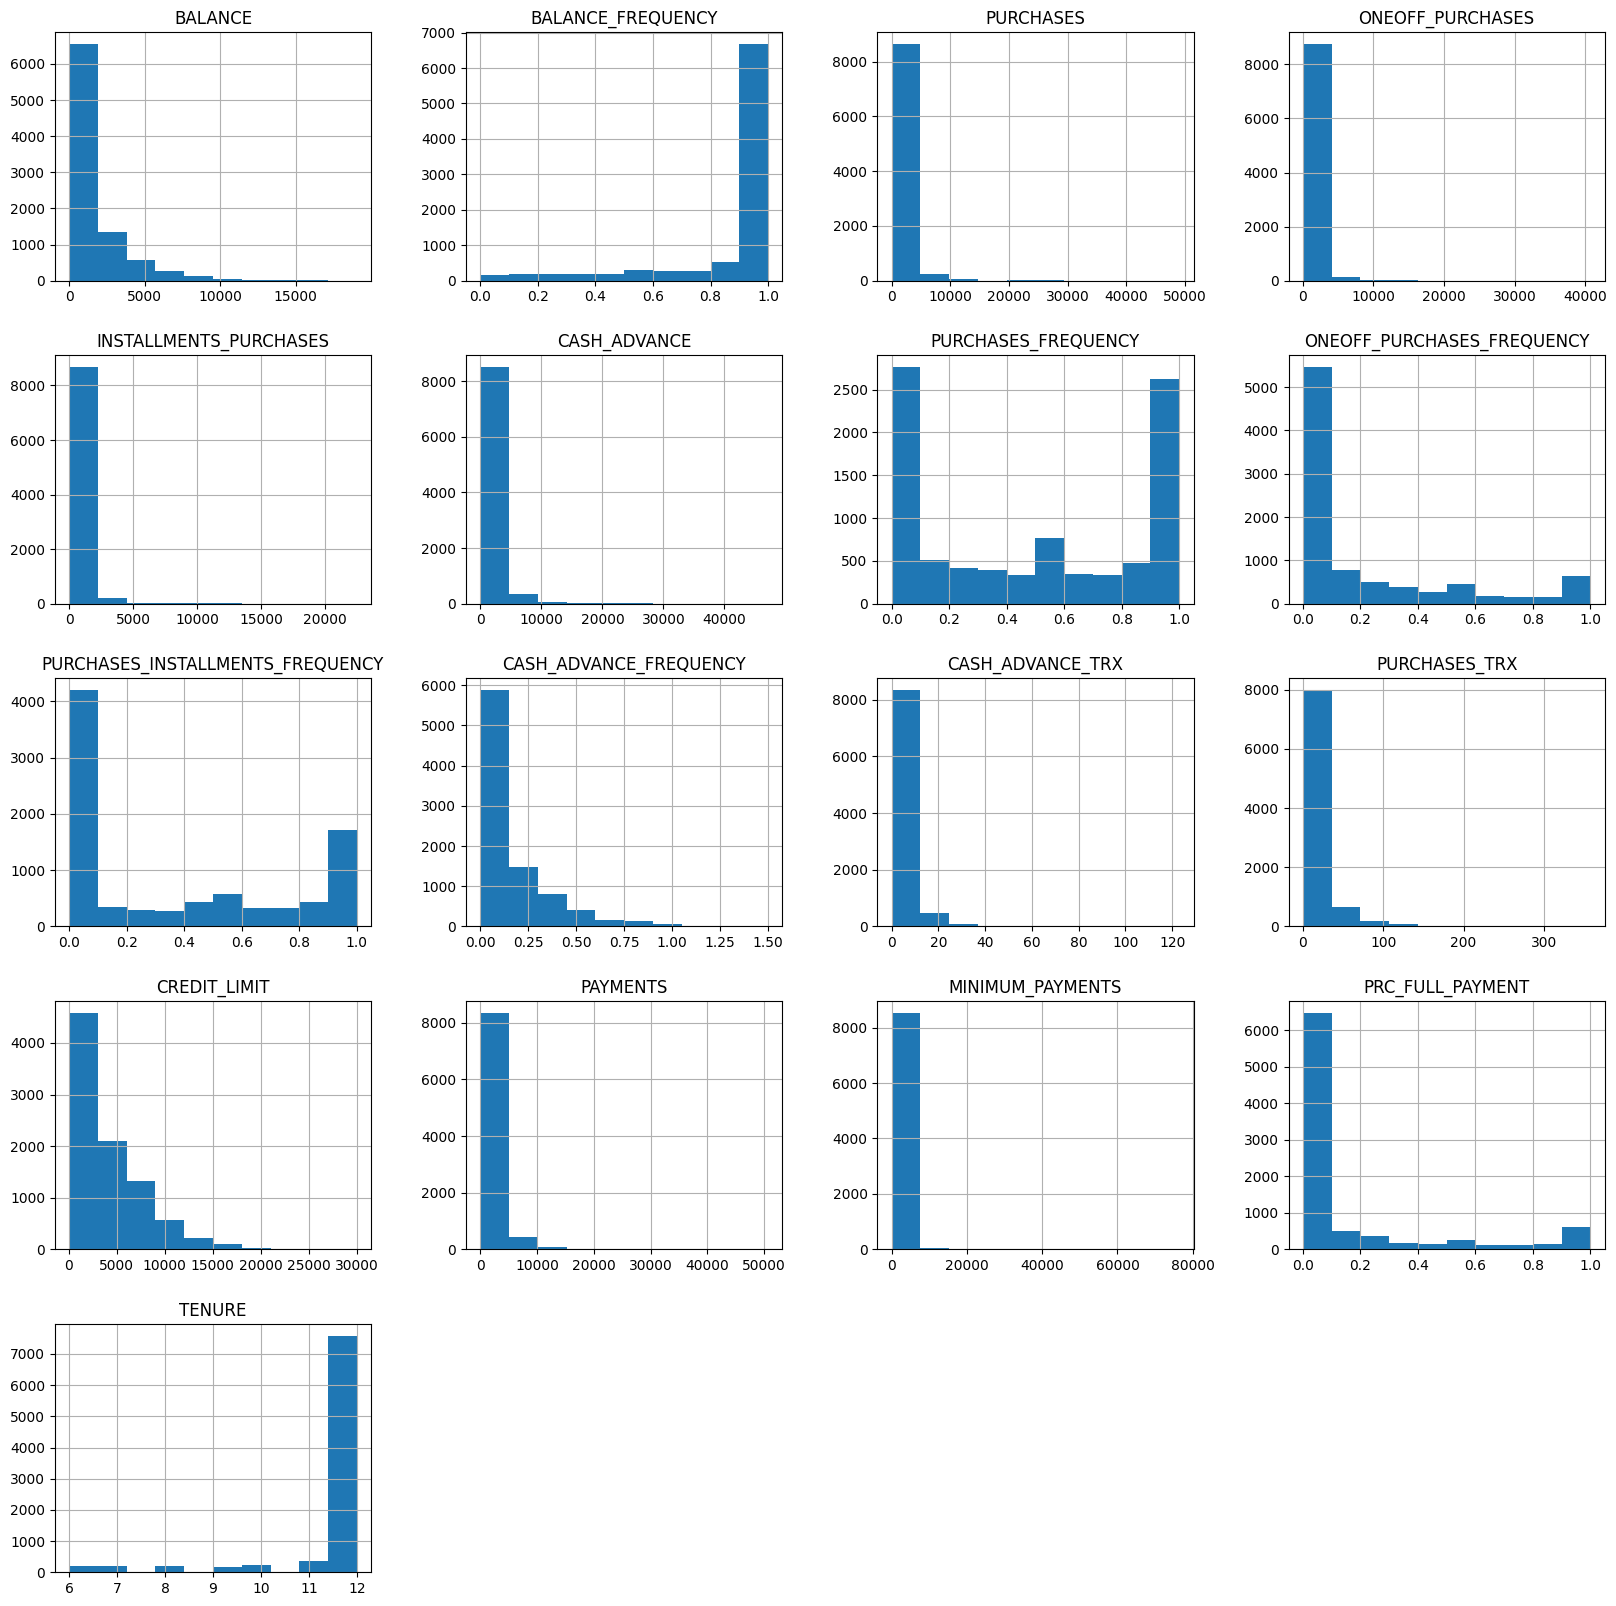

In [13]:
df.hist(figsize=(20,20))


## 3.6. Outliers

In [14]:
num_cols = [col for col in df.columns if col != 'CUST_ID']
num_cols

['BALANCE',
 'BALANCE_FREQUENCY',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'PURCHASES_FREQUENCY',
 'ONEOFF_PURCHASES_FREQUENCY',
 'PURCHASES_INSTALLMENTS_FREQUENCY',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS',
 'PRC_FULL_PAYMENT',
 'TENURE']

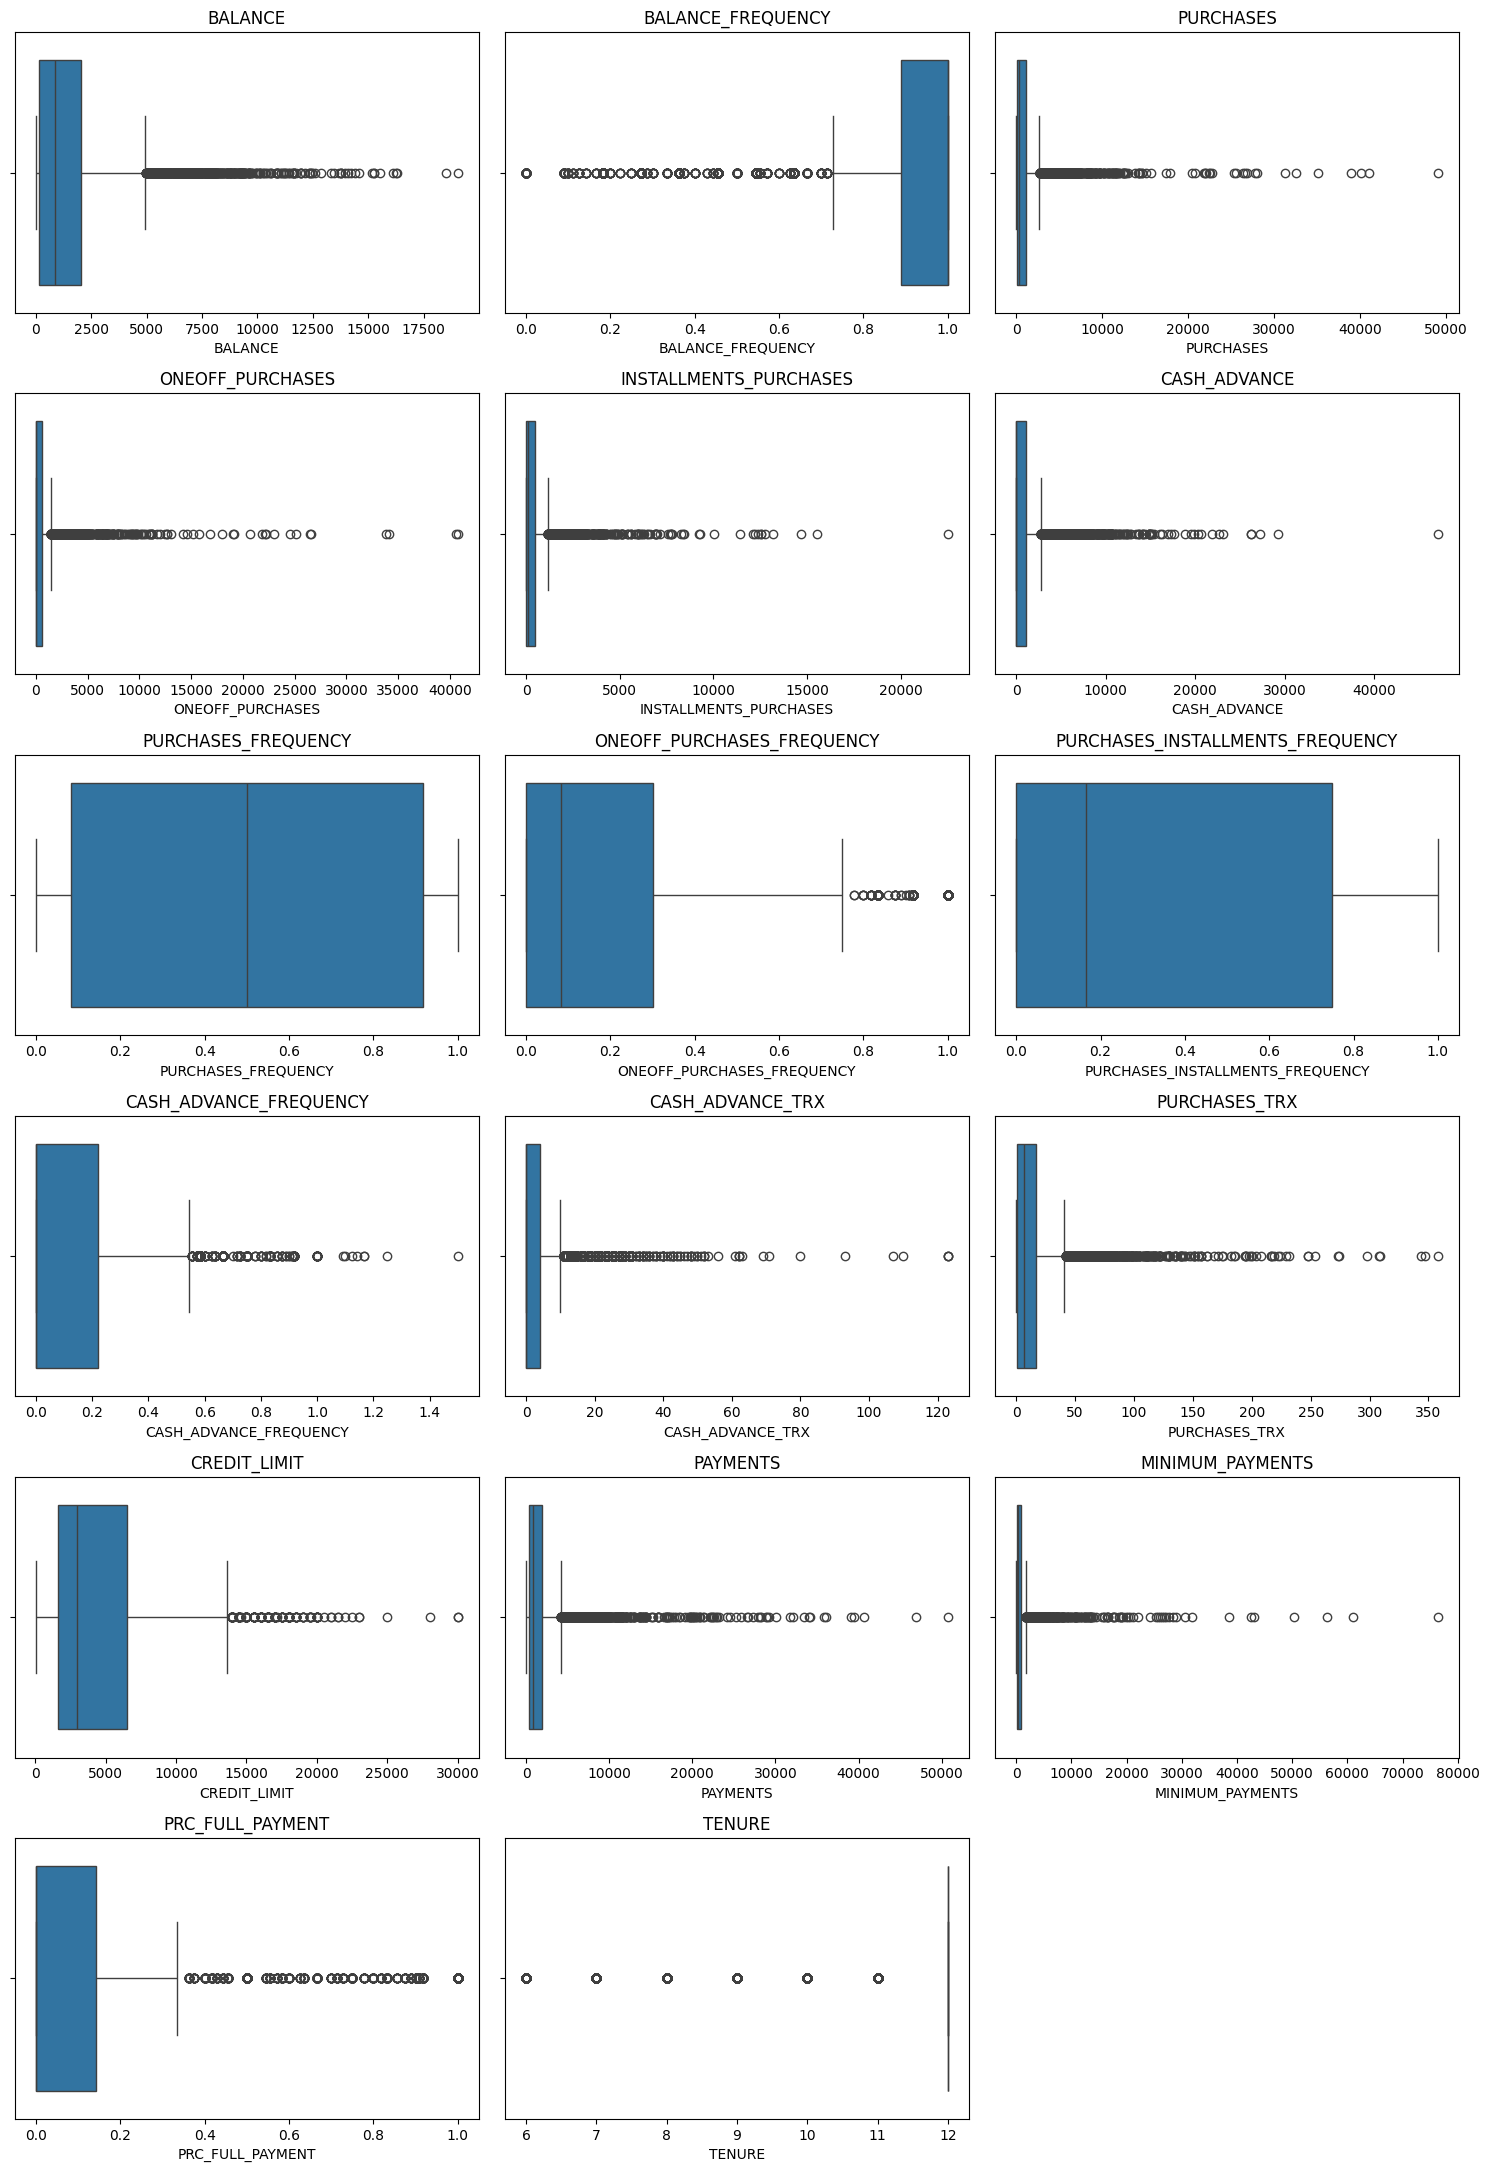

In [15]:
plt.figure(figsize=(15, 25))
for i, col in enumerate(num_cols , 1):
    plt.subplot(7, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()

In [16]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## 3.7. Correlation

Text(0.5, 1.0, 'Correlation Heatmap')

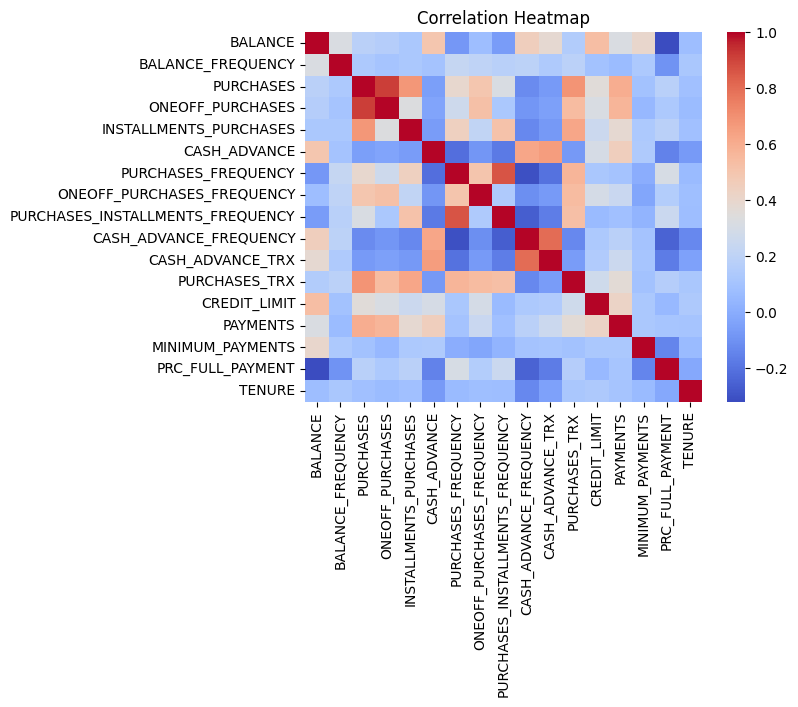

In [17]:
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")

In [18]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

## 3.8. Exploration Summary


* `CUST_ID` should be dropped
* Data types are correct
* Missing values:
  * `CREDIT_LIMIT`: 1 (0.0112%) -> drop
  * `MINIMUM_PAYMENTS`	313 (3.4972%) -> median imputation
* No duplicated rows
* All columns have outliers
* Many features are highly correlated such as ('PURCHASES' and
       'ONEOFF_PURCHASES'), ('PURCHASES' and 'INSTALLMENTS_PURCHASES'), ('BALANCE', 'PRC_FULL_PAYMENT'), ...

# 4. Data Pipeline

## 4.1. Preprocessing

There is only 1 missing value in `'CREDIT_LIMIT'` column, so it will be dropped.

In [19]:
df.dropna(subset=['CREDIT_LIMIT'], inplace=True)

In [20]:
df['CREDIT_LIMIT'].isna().sum()

np.int64(0)

Preprocessing consists of 3 steps:
  1. Median Imputation
  2. Power Transformation (due to outliers)
  3. Standardization (applied by `PowerTransformer` by default)

Then, PCA will be applied in the `full_pipeline`

In [21]:
num_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('power', PowerTransformer())
    ]
)

In [22]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_transformer, num_cols)
    ],
    remainder='drop'
)

## 4.2. Number of Principle Components

In [23]:
df_processed = preprocessor.fit_transform(df)

In [24]:
df_processed.shape

(8949, 17)

In [25]:
variance_ratios = []
n_features = df_processed.shape[1]

pca = PCA(n_components=n_features, random_state=42)
pca.fit(df_processed)

for i in range(1, n_features + 1):
  variance_ratios.append(np.sum(pca.explained_variance_ratio_[:i]))

In [26]:
variance_ratios

[np.float64(0.357507682644502),
 np.float64(0.5826482048483432),
 np.float64(0.6828052946259577),
 np.float64(0.760182132913504),
 np.float64(0.8280560404810072),
 np.float64(0.8749368924996566),
 np.float64(0.914735437634103),
 np.float64(0.9452086539353768),
 np.float64(0.9655397421033818),
 np.float64(0.9753084399411756),
 np.float64(0.9823116123959003),
 np.float64(0.98814393076853),
 np.float64(0.9921712916771872),
 np.float64(0.9957081503233361),
 np.float64(0.998030625945015),
 np.float64(0.9991080110346853),
 np.float64(1.0)]

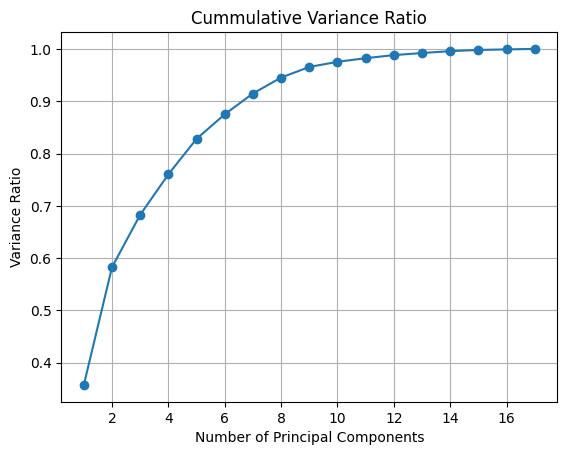

In [27]:
plt.plot(range(1, n_features + 1) ,variance_ratios, marker='o')
plt.title('Cummulative Variance Ratio')
plt.xlabel('Number of Principal Components')
plt.ylabel('Variance Ratio')
plt.grid()

In [28]:
n_pc_90 = np.argmax(np.array(variance_ratios) > 0.9) + 1
n_pc_95 = np.argmax(np.array(variance_ratios) > 0.95) + 1

n_pc_90, n_pc_95

(np.int64(7), np.int64(9))

> 9 PCs carry 96.5% of variance

## 4.2. Full Pipeline

In [29]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=n_pc_95, random_state=42)),
    ('kmeans', KMeans(random_state=42, init='k-means++')) # n_clusters will be set later after the elbow method
])

# 5. Experimentation

## 5.1. Elbow Method

In [30]:
k_values = range(2, 11)
inertia_scores = []
silhouette_scores = []

for k in k_values:
  full_pipeline.set_params(kmeans__n_clusters=k)
  full_pipeline.fit(df)
  inertia_scores.append(full_pipeline.named_steps['kmeans'].inertia_)

  lables = full_pipeline.predict(df)
  silhouette = silhouette_score(df_processed, lables)
  silhouette_scores.append(silhouette)

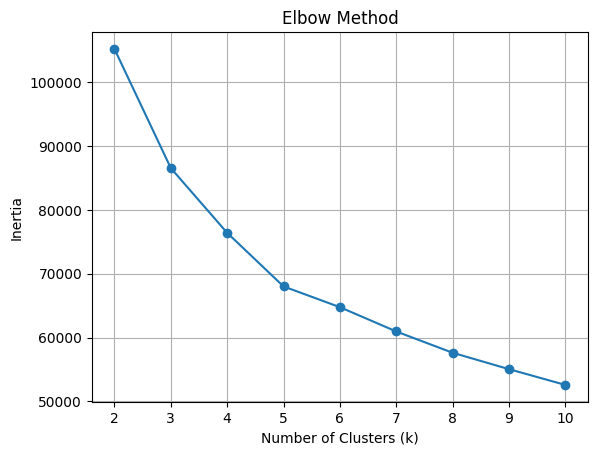

In [31]:
plt.plot(k_values, inertia_scores, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid()

> The elbow is not clear

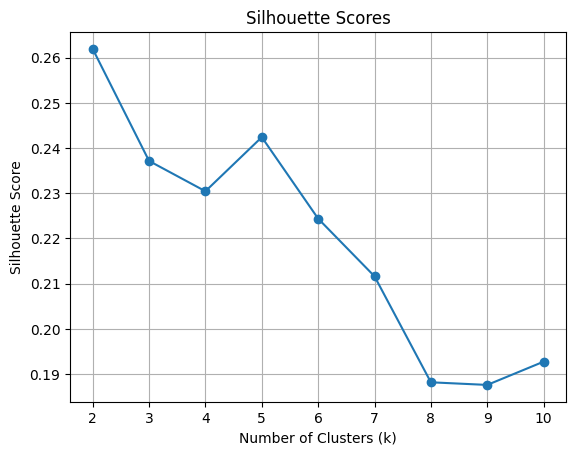

In [32]:
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid()

In [33]:
full_pipeline.set_params(kmeans__n_clusters=5)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power',
                                                                   PowerTransformer())]),
                                                  ['BALANCE',
                                                   'BALANCE_FREQUENCY',
                                                   'PURCHASES',
                                                   'ONEOFF_PURCHASES',
                                                   'INSTALLMENTS_PURCHASES',
                                                   'CASH_ADVANCE',
                                                   'PURCHASES_FREQUENCY',
                                                   'ONEOFF_PURCHASES_FREQUENCY',
                                                   'PURCHASES_INSTALLMENTS_FREQUENCY',
                                                   'CASH_ADVANCE_FREQUENCY',
                                                   'CASH_ADVANCE_TRX',
                                                   'PURCHASES_TRX',
                                                   'CREDIT_LIMIT', 'PAYMENTS',
                                                   'MINIMUM_PAYMENTS',
                                                   'PRC_FULL_PAYMENT',
                                                   'TENURE'])])),
                ('pca', PCA(n_components=np.int64(9), random_state=42)),
                ('kmeans', KMeans(n_clusters=5, random_state=42))])

## 5.2. Fit Model

In [34]:
full_pipeline.fit(df)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power',
                                                                   PowerTransformer())]),
                                                  ['BALANCE',
                                                   'BALANCE_FREQUENCY',
                                                   'PURCHASES',
                                                   'ONEOFF_PURCHASES',
                                                   'INSTALLMENTS_PURCHASES',
                                                   'CASH_ADVANCE',
                                                   'PURCHASES_FREQUENCY',
                                                   'ONEOFF_PURCHASES_FREQUENCY',
                                                   'PURCHASES_INSTALLMENTS_FREQUENCY',
                                                   'CASH_ADVANCE_FREQUENCY',
                                                   'CASH_ADVANCE_TRX',
                                                   'PURCHASES_TRX',
                                                   'CREDIT_LIMIT', 'PAYMENTS',
                                                   'MINIMUM_PAYMENTS',
                                                   'PRC_FULL_PAYMENT',
                                                   'TENURE'])])),
                ('pca', PCA(n_components=np.int64(9), random_state=42)),
                ('kmeans', KMeans(n_clusters=5, random_state=42))])

## 5.3. Assign Lables

In [35]:
labels = full_pipeline.named_steps['kmeans'].labels_

In [36]:
df_clustered = df.copy()
df_clustered['Cluster'] = labels
df_clustered.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,2
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,3
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12,3
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


## 5.4. K-Means Evaluation

In [37]:
X_processed = full_pipeline.named_steps['preprocessor'].fit_transform(df)
lables = full_pipeline.predict(df)

silhouette_score(X_processed, labels)

np.float64(0.24242354606470035)

## 5.5. Visualization

In [38]:
PCs = full_pipeline.named_steps['pca'].transform(df_processed)
df_pca = pd.DataFrame(PCs, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9'])
df_pca['Cluster'] = full_pipeline.named_steps['kmeans'].labels_.astype(str)
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Cluster
0,-0.256402,-3.117240,-0.212140,-1.039162,0.060030,-0.155493,-0.679016,-0.873231,-0.303741,2
1,-3.480136,0.875292,-0.180773,1.335073,2.105084,0.295592,0.679257,-0.268776,0.647957,0
2,1.337092,1.187997,2.191266,-1.742006,0.009938,0.361336,0.290415,0.722455,0.272510,3
3,-1.373930,-0.533114,2.053472,-0.580049,-0.582991,0.741878,-2.211714,0.887097,1.522410,3
4,-1.009702,-1.406326,1.019393,-1.981967,0.287524,-0.600037,0.931382,-0.426215,-0.624754,3


In [39]:
fig = px.scatter_3d(
    df_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    title='Customer Segments',
    opacity=0.6,
)
fig.show()

In [40]:
fig = px.scatter(
    df_pca,
    x='PC1',
    y='PC2',
    color='Cluster',
    title='Customer Segments',
    opacity=0.6,
)
fig.show()

# 6. Interpretation

## 6.1. Interpret Key Featurs of Clusters

In [58]:
key_features = ['BALANCE', 'PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PRC_FULL_PAYMENT']

In [59]:
df_clustered['Cluster'].value_counts()

,count
Cluster,
0,2509
2,1987
1,1538
4,1536
3,1379


In [60]:
df_clustered.groupby('Cluster')[key_features].mean().T

Cluster,0,1,2,3,4
BALANCE,2145.374266,1517.370769,294.639653,649.921745,3127.526013
PURCHASES_FREQUENCY,0.024978,0.892700,0.722837,0.310309,0.708856
PURCHASES_INSTALLMENTS_FREQUENCY,0.007033,0.679914,0.681955,0.035135,0.517491
CASH_ADVANCE,1978.750911,14.660655,15.448607,41.302432,2399.624378
CREDIT_LIMIT,4029.462420,6561.731423,2946.534164,3958.303558,5667.773438
PRC_FULL_PAYMENT,0.040203,0.278525,0.321250,0.104770,0.041473


## 6.2. Profiling


| | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 | Cluster 4 |
|---|---|---|---|---|---|
| Balance | High | Moderate | Very Low | Moderate | Very High |
| Purchases Frequency | Very Low | Very High | High | Low | High |
| Installment Frequency | Very Low | Very High | High | Low | High |
| Cash Advance | Very High | Very Low | Very Low | Low | Very High |
| Credit Limit | Moderate | Very High | Low | Moderate | High |
| Full Payment Percentage | Very Low | Moderate | Highest | Low | Very Low |

* Cluster 0: **"Financially Stressed"**
  * Rarely shop with the card
  * Use it mainly to withdraw cash
  * Carry significant debt
  * Almost never pay full balance
  * Liquidity problems
  * High credit risk
---
* Cluster 1: **"Premium Active Transactors"**
  * Use card very frequently
  * Prefer purchases over cash
  * Have premium limits
  * Low risk
---
* Cluster 2: **"Disciplined Low-Balance Users"**
  * Use the card frequently
  * Prefer installment purchases
  * Keep balances low
  * Pay responsibly
  * Low risk
---
* Cluster 3: **"Passive Credit Users"**
  * Infrequent users
  * Sometimes carry balance
  * Low engagement
  * Medium risk
---
* Cluster 4: **"High-Exposure Debt Carriers"**
  * Use the card heavily
  * Combine purchases + installments + cash advance
  * Rarely pay full balance
  * Carry large debt
  * Very high interest revenue
  * High risk

---

 # 7. Hierarchical Clustering

## 7.1. Dendrogram

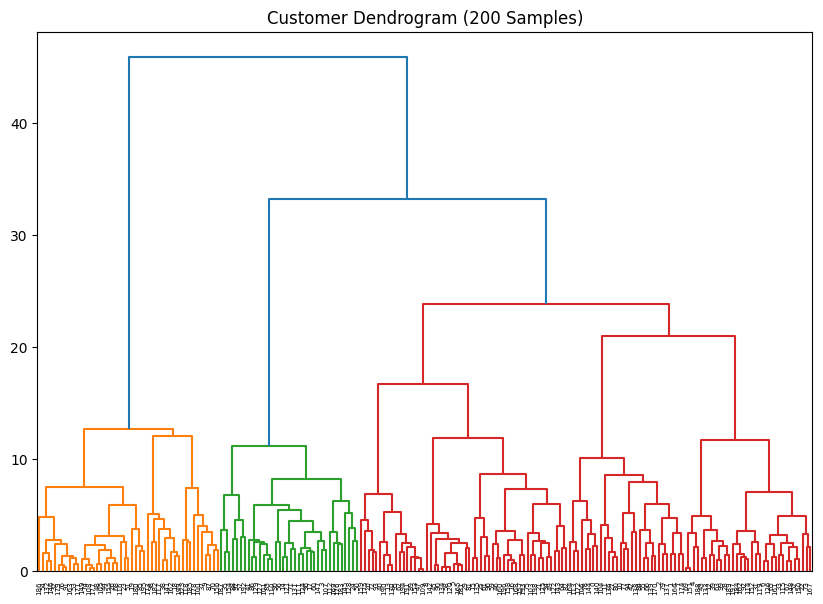

In [ ]:
sample_indices = np.random.choice(len(df_pca), size=200, replace=False)
x_sample = df_pca.iloc[sample_indices]

plt.figure(figsize=(10, 7))
plt.title("Customer Dendrogram (200 Samples)")
dendrogram = shc.dendrogram(shc.linkage(x_sample, method='ward'))

## 7.2. Hierarchical Clustering Evalustion

In [ ]:
hierarical = AgglomerativeClustering(n_clusters=6, linkage='ward')
hierarical_labels = hierarical.fit_predict(df_pca)

In [ ]:
print(f"Hierarchical Clustering Silhouette: {silhouette_score(df_pca, hierarical_labels)}")

Hierarchical Clustering Silhouette: 0.2556563640669945


In [ ]:
k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
  hierarical = AgglomerativeClustering(n_clusters=k, linkage='ward')
  hierarical_labels = hierarical.fit_predict(df_pca)

  silhouette = silhouette_score(df_pca, hierarical_labels)
  silhouette_scores.append(silhouette)

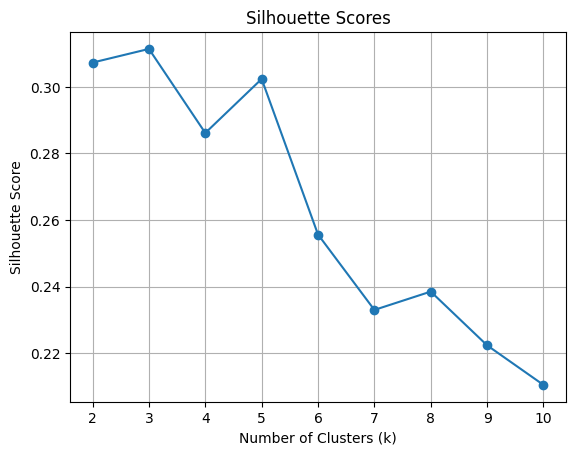

In [ ]:
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid()